In [2]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from utils import plot_top_n_distribution, calculate_range
import numpy as np

In [3]:
df_charging_data = pd.read_csv('../data/charging_sessions.csv')
df_weather = pd.read_csv('../data/weather_burbank_airport.csv')

### General data overview 

#### EV charging data

In [4]:
df_charging_data

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66445,10083,5d574ad2f9af8b4c10c03652,2019-07-31 18:08:04+00:00,2019-07-31 23:29:18+00:00,2019-07-31 23:30:18+00:00,28.787,1_1_179_809_2019-07-31 18:08:04.432654,1,AG-3F27,1-1-179-809,America/Los_Angeles,393.0,"[{'WhPerMile': 240, 'kWhRequested': 31.2, 'mil..."
66446,10084,5d574ad2f9af8b4c10c03653,2019-07-31 18:40:41+00:00,2019-08-01 00:59:42+00:00,2019-07-31 21:44:23+00:00,7.787,1_1_179_810_2019-07-31 18:40:40.900203,1,AG-3F30,1-1-179-810,America/Los_Angeles,220.0,"[{'WhPerMile': 333, 'kWhRequested': 6.66, 'mil..."
66447,10085,5d574ad2f9af8b4c10c03654,2019-07-31 19:04:40+00:00,2019-07-31 22:44:22+00:00,2019-07-31 22:45:21+00:00,11.274,1_1_191_795_2019-07-31 19:04:40.098273,1,AG-4F51,1-1-191-795,America/Los_Angeles,1974.0,"[{'WhPerMile': 333, 'kWhRequested': 19.98, 'mi..."
66448,10086,5d574ad2f9af8b4c10c03655,2019-07-31 19:19:47+00:00,2019-08-01 00:34:51+00:00,2019-07-31 21:25:30+00:00,11.589,1_1_191_778_2019-07-31 19:19:46.919358,1,AG-4F43,1-1-191-778,America/Los_Angeles,942.0,"[{'WhPerMile': 275, 'kWhRequested': 22.0, 'mil..."


In [5]:
df_charging_data.describe()

,Unnamed: 0,kWhDelivered,siteID,userID
count,66450.000000,66450.000000,66450.000000,49187.000000
mean,4726.102062,11.787916,1.472656,1800.494582
std,3568.025394,10.314789,0.499256,2617.548614
min,0.000000,0.501000,1.000000,1.000000
25%,1845.000000,5.097000,1.000000,431.000000
50%,3960.000000,9.140000,1.000000,818.000000
75%,7027.000000,14.183000,2.000000,1805.000000
max,15291.000000,108.797242,2.000000,19923.000000


In [6]:
df_charging_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66450 entries, 0 to 66449
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        66450 non-null  int64  
 1   id                66450 non-null  object 
 2   connectionTime    66450 non-null  object 
 3   disconnectTime    66450 non-null  object 
 4   doneChargingTime  62362 non-null  object 
 5   kWhDelivered      66450 non-null  float64
 6   sessionID         66450 non-null  object 
 7   siteID            66450 non-null  int64  
 8   spaceID           66450 non-null  object 
 9   stationID         66450 non-null  object 
 10  timezone          66450 non-null  object 
 11  userID            49187 non-null  float64
 12  userInputs        49187 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 6.6+ MB


In [7]:
df_charging_data.isnull().sum()

Unnamed: 0              0
id                      0
connectionTime          0
disconnectTime          0
doneChargingTime     4088
kWhDelivered            0
sessionID               0
siteID                  0
spaceID                 0
stationID               0
timezone                0
userID              17263
userInputs          17263
dtype: int64

In [8]:
df_charging_data

,Unnamed: 0,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,userInputs
0,0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,"[{'WhPerMile': 250, 'kWhRequested': 25.0, 'mil..."
1,1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,"[{'WhPerMile': 280, 'kWhRequested': 70.0, 'mil..."
2,2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
3,3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile..."
4,4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
66445,10083,5d574ad2f9af8b4c10c03652,2019-07-31 18:08:04+00:00,2019-07-31 23:29:18+00:00,2019-07-31 23:30:18+00:00,28.787,1_1_179_809_2019-07-31 18:08:04.432654,1,AG-3F27,1-1-179-809,America/Los_Angeles,393.0,"[{'WhPerMile': 240, 'kWhRequested': 31.2, 'mil..."
66446,10084,5d574ad2f9af8b4c10c03653,2019-07-31 18:40:41+00:00,2019-08-01 00:59:42+00:00,2019-07-31 21:44:23+00:00,7.787,1_1_179_810_2019-07-31 18:40:40.900203,1,AG-3F30,1-1-179-810,America/Los_Angeles,220.0,"[{'WhPerMile': 333, 'kWhRequested': 6.66, 'mil..."
66447,10085,5d574ad2f9af8b4c10c03654,2019-07-31 19:04:40+00:00,2019-07-31 22:44:22+00:00,2019-07-31 22:45:21+00:00,11.274,1_1_191_795_2019-07-31 19:04:40.098273,1,AG-4F51,1-1-191-795,America/Los_Angeles,1974.0,"[{'WhPerMile': 333, 'kWhRequested': 19.98, 'mi..."
66448,10086,5d574ad2f9af8b4c10c03655,2019-07-31 19:19:47+00:00,2019-08-01 00:34:51+00:00,2019-07-31 21:25:30+00:00,11.589,1_1_191_778_2019-07-31 19:19:46.919358,1,AG-4F43,1-1-191-778,America/Los_Angeles,942.0,"[{'WhPerMile': 275, 'kWhRequested': 22.0, 'mil..."


#### Weather data

In [9]:
df_weather

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 08:53:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 09:53:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 10:53:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 11:53:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 12:53:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...
29239,Burbank,2021-01-01 03:53:00,13.0,33.0,Fair,986.81,0.0,0.0,13.0
29240,Burbank,2021-01-01 04:53:00,12.0,33.0,Fair,986.81,11.0,0.0,12.0
29241,Burbank,2021-01-01 05:53:00,12.0,33.0,Fair,987.47,9.0,0.0,12.0
29242,Burbank,2021-01-01 06:53:00,11.0,33.0,Fair,987.14,13.0,0.0,11.0


In [10]:
df_weather.describe()

,temperature,cloud_cover,pressure,windspeed,precipitation,felt_temperature
count,29219.000000,29224.000000,29236.000000,29158.000000,29244.000000,29218.000000
mean,17.885622,30.107993,986.879400,8.566568,0.059360,17.731433
std,6.454604,5.400388,3.607065,6.699889,0.471682,6.321100
min,2.000000,4.000000,971.000000,0.000000,0.000000,0.000000
25%,13.000000,26.000000,984.500000,6.000000,0.000000,13.000000
50%,17.000000,33.000000,986.480000,7.000000,0.000000,17.000000
75%,22.000000,34.000000,989.110000,13.000000,0.000000,22.000000
max,46.000000,47.000000,999.650000,57.000000,18.540000,42.000000


In [11]:
df_weather.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29244 entries, 0 to 29243
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   city                     29244 non-null  object 
 1   timestamp                29244 non-null  object 
 2   temperature              29219 non-null  float64
 3   cloud_cover              29224 non-null  float64
 4   cloud_cover_description  29224 non-null  object 
 5   pressure                 29236 non-null  float64
 6   windspeed                29158 non-null  float64
 7   precipitation            29244 non-null  float64
 8   felt_temperature         29218 non-null  float64
dtypes: float64(6), object(3)
memory usage: 2.0+ MB


### Data preparation

#### Weather Data

In [12]:
# transform date:
df_weather["timestamp"] = df_weather["timestamp"].apply(
    lambda x: pd.to_datetime(x, utc=True))
# Transform the timestamps from UTC to the correct timezone
df_weather["timestamp"] = df_weather["timestamp"].apply(lambda x: x.tz_convert('America/Los_Angeles'))

In [13]:
df_weather

,city,timestamp,temperature,cloud_cover,cloud_cover_description,pressure,windspeed,precipitation,felt_temperature
0,Burbank,2018-01-01 00:53:00-08:00,9.0,33.0,Fair,991.75,9.0,0.0,8.0
1,Burbank,2018-01-01 01:53:00-08:00,9.0,33.0,Fair,992.08,0.0,0.0,9.0
2,Burbank,2018-01-01 02:53:00-08:00,9.0,21.0,Haze,992.08,0.0,0.0,9.0
3,Burbank,2018-01-01 03:53:00-08:00,9.0,29.0,Partly Cloudy,992.08,0.0,0.0,9.0
4,Burbank,2018-01-01 04:53:00-08:00,8.0,33.0,Fair,992.08,0.0,0.0,8.0
...,...,...,...,...,...,...,...,...,...
29239,Burbank,2020-12-31 19:53:00-08:00,13.0,33.0,Fair,986.81,0.0,0.0,13.0
29240,Burbank,2020-12-31 20:53:00-08:00,12.0,33.0,Fair,986.81,11.0,0.0,12.0
29241,Burbank,2020-12-31 21:53:00-08:00,12.0,33.0,Fair,987.47,9.0,0.0,12.0
29242,Burbank,2020-12-31 22:53:00-08:00,11.0,33.0,Fair,987.14,13.0,0.0,11.0


#### Drop duplicates

In [14]:
# Remove the "Unnamed: 0" column, as it represents the index and restarts from 1 at a certain point in the dataset
df_charging_data = df_charging_data.drop(columns=["Unnamed: 0"])

In [15]:
# Check for duplicates
duplicate_rows = df_charging_data.duplicated()
duplicate_count = duplicate_rows.sum()
duplicate_percentage = round(duplicate_count / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of duplicate rows in the data: {duplicate_count}")
print(f"Percentage of duplicate rows in the data: {duplicate_percentage}%")

Absolute number of duplicate rows in the data: 1413
Percentage of duplicate rows in the data: 2.13%


In [16]:
# Drop duplicate rows
df_charging_data = df_charging_data.drop_duplicates()

In [17]:
# Check for duplicates
duplicate_rows = df_charging_data.duplicated()
duplicate_count = duplicate_rows.sum()
duplicate_percentage = round(duplicate_count / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of duplicate rows in the data: {duplicate_count}")
print(f"Percentage of duplicate rows in the data: {duplicate_percentage}%")

Absolute number of duplicate rows in the data: 0
Percentage of duplicate rows in the data: 0.0%


#### Normalize nested data 

A nested JSON structure for the column "userInputs" can be seen. 
To make it easier to analyze the data, the nested structure should be broken down into multiple columns. 
Some of the rows might have multiple user inputs with different timestamps. 
-> These rows should be looked at more closely first.

In [18]:
# For col userInputs: Change string representation of Python list into a list to be able to count the length
df_charging_data['userInputs'] = df_charging_data['userInputs'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else None)

# Count the number of entries in each list
df_charging_data['inputCount'] = df_charging_data['userInputs'].apply(
    lambda x: len(x) if isinstance(x, list) else 0)

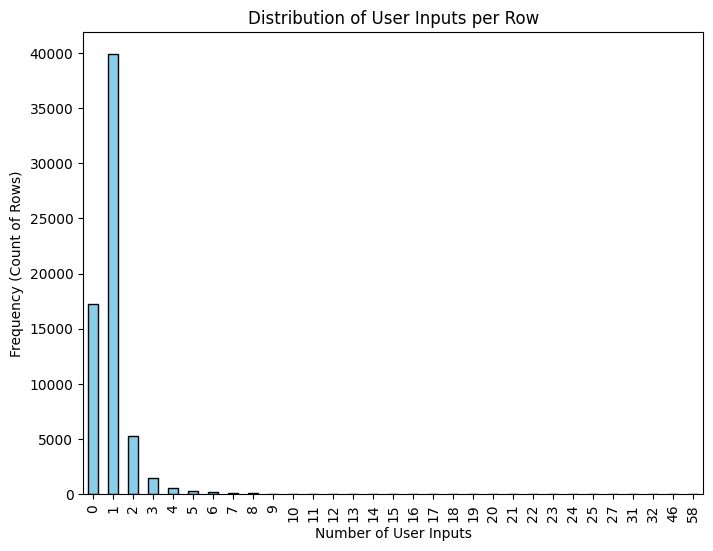

In [19]:
%matplotlib inline
# Visualize the distribution for inputCount
distribution = df_charging_data['inputCount'].value_counts().sort_index()

plt.figure(figsize=(8, 6))
distribution.plot(kind='bar', color='skyblue', edgecolor='black')
plt.title("Distribution of User Inputs per Row")
plt.xlabel("Number of User Inputs")
plt.ylabel("Frequency (Count of Rows)")
plt.show()

In [20]:
# Count rows with more than one user input
count_multiple_inputs = (df_charging_data['inputCount'] > 1).sum()
per_multiple_inputs = round(count_multiple_inputs / df_charging_data.shape[0], 4) * 100
print(f"Absolute number of rows with multiple user inputs: {count_multiple_inputs}")
print(f"Percentage of rows with multiple user inputs: {per_multiple_inputs}%")

Absolute number of rows with multiple user inputs: 7905
Percentage of rows with multiple user inputs: 12.15%


-> More than 10% of the rows have multiple user inputs, so these should be looked at more closely instead of always taking the first dictionary of the list.

Compare the difference between the user inputs in a single session

In [21]:
# Dataframe with all rows with more than one user input
df_multiple_inputs = df_charging_data[df_charging_data["inputCount"] > 1].copy()

# Columns to calculate the range for
columns_of_interest = ["WhPerMile", "kWhRequested", "milesRequested", "minutesAvailable", 
                       "modifiedAt", "requestedDeparture", "userID"]						
# Calculate range for each column safely
for column in columns_of_interest:
    df_multiple_inputs[f"{column}_range"] = df_multiple_inputs["userInputs"].apply(
        lambda x: calculate_range(x, column)
    )

# Select only the relevant columns to create final comparison DataFrame
cols = ["inputCount"] + ["userInputs"] + [f"{col}_range" for col in columns_of_interest]
user_inputs_range_df = df_multiple_inputs[cols]

In [22]:
user_inputs_range_df.head()

,inputCount,userInputs,WhPerMile_range,kWhRequested_range,milesRequested_range,minutesAvailable_range,modifiedAt_range,requestedDeparture_range,userID_range
3,2,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,0,0 days 00:00:16,0 days 00:00:00,0
17,3,"[{'WhPerMile': 400, 'kWhRequested': 8.0, 'mile...",0,0.0,0,139,0 days 02:41:46,0 days 02:19:00,0
19,2,"[{'WhPerMile': 400, 'kWhRequested': 16.0, 'mil...",0,0.0,0,287,0 days 00:00:09,0 days 04:47:00,0
20,2,"[{'WhPerMile': 350, 'kWhRequested': 42.0, 'mil...",0,14.0,40,44,0 days 01:00:19,0 days 00:44:00,0
31,3,"[{'WhPerMile': 600, 'kWhRequested': 78.0, 'mil...",0,12.0,20,2,0 days 00:02:43,0 days 00:02:00,0


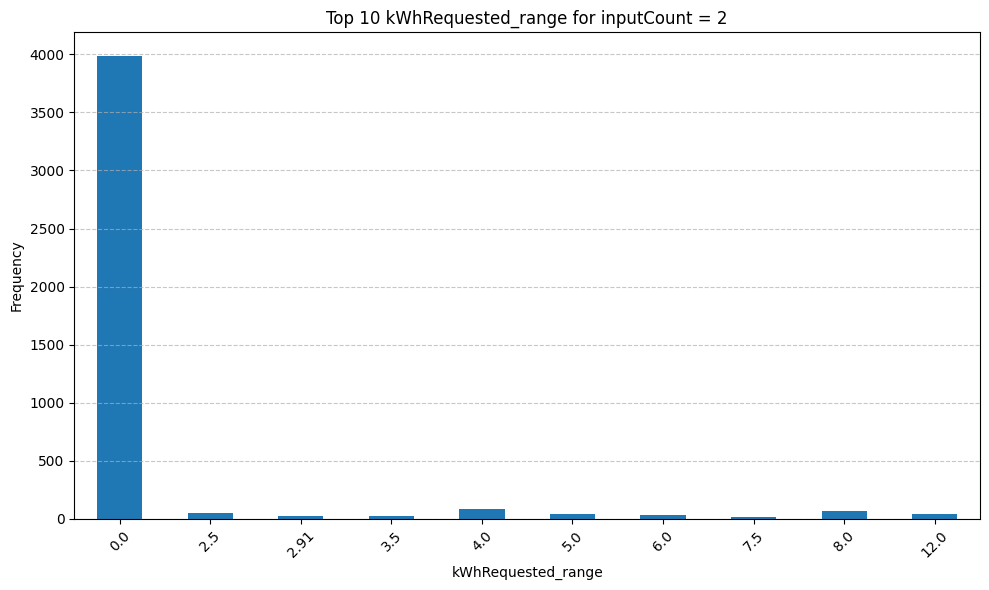

In [23]:
plot_top_n_distribution(user_inputs_range_df, 2, 'kWhRequested_range')

The function above shows the range (max - min value) of the given user inputs in a row, if there were more than one input given. Executing the function with varying parameters leads to very similar results:

Most of the time when multiple user inputs are stored, the inputs the user gave were the exact same, just with different timestamps for "modifiedAt" or a later departure time.
Therefore it seems like a good solution to always take the last input of the driver and don't do complicated data aggregation or splitting rows up into individual rows with an additional input index as a column.  
In most cases it won't make a difference regarding the data and where it does it seems to be the most logical way to take the final input of the driver.

Unnest the "userInputs" column

In [24]:
# Process the column to get the last dictionary or an empty dictionary
processed_data = [
    lst[-1] if lst else {} 
    for lst in df_charging_data['userInputs']
]

# Convert the list of dictionaries into a new DataFrame
normalized_df = pd.json_normalize(processed_data)

normalized_df.head()

,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture,userID
0,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT",194.0
1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT",4275.0
2,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT",344.0
3,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT",1117.0
4,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT",334.0


In [25]:
# Concatenate dataframes and drop userInputs column as the data is now stored in new columns

full_charging_df = pd.concat([df_charging_data.drop(columns=['userInputs']), 
                     normalized_df.drop(columns=['userID'])], axis=1)

In [26]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,userID,inputCount,WhPerMile,kWhRequested,milesRequested,minutesAvailable,modifiedAt,paymentRequired,requestedDeparture
0,5e23b149f9af8b5fe4b973cf,2020-01-02 13:08:54+00:00,2020-01-02 19:11:15+00:00,2020-01-02 17:31:35+00:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,194.0,1,250.0,25.0,100.0,463.0,"Thu, 02 Jan 2020 13:09:39 GMT",True,"Thu, 02 Jan 2020 20:51:54 GMT"
1,5e23b149f9af8b5fe4b973d0,2020-01-02 13:36:50+00:00,2020-01-02 22:38:21+00:00,2020-01-02 20:18:05+00:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,4275.0,1,280.0,70.0,250.0,595.0,"Thu, 02 Jan 2020 13:37:11 GMT",True,"Thu, 02 Jan 2020 23:31:50 GMT"
2,5e23b149f9af8b5fe4b973d1,2020-01-02 13:56:35+00:00,2020-01-03 00:39:22+00:00,2020-01-02 16:35:06+00:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,344.0,1,400.0,8.0,20.0,60.0,"Thu, 02 Jan 2020 13:57:17 GMT",True,"Thu, 02 Jan 2020 14:56:35 GMT"
3,5e23b149f9af8b5fe4b973d2,2020-01-02 13:59:58+00:00,2020-01-02 16:38:39+00:00,2020-01-02 15:18:45+00:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,1117.0,2,400.0,8.0,20.0,65.0,"Thu, 02 Jan 2020 14:00:19 GMT",True,"Thu, 02 Jan 2020 15:04:58 GMT"
4,5e23b149f9af8b5fe4b973d3,2020-01-02 14:00:01+00:00,2020-01-02 22:08:40+00:00,2020-01-02 18:17:30+00:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,334.0,1,400.0,16.0,40.0,504.0,"Thu, 02 Jan 2020 14:00:13 GMT",True,"Thu, 02 Jan 2020 22:24:01 GMT"


#### Exporation and Preparation of the Time Data

First transform the the time zones to the correct time zone

In [27]:
time_columns = ["doneChargingTime", "connectionTime", "disconnectTime", "modifiedAt", "requestedDeparture"]

In [28]:
# Transform to pandas datetime datatype
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda x: pd.to_datetime(x, utc=True))

In [29]:
# Transform the timestamps from UTC to the correct timezone
full_charging_df[time_columns] = full_charging_df[time_columns].apply(
    lambda col: col.dt.tz_convert("America/Los_Angeles"))

In [30]:
# Check new timestamps
full_charging_df["connectionTime"]
# -> -08:00 and -07:00 are the offsets from UTC time (-8 hours in winter, -7 in summer)

0       2020-01-02 05:08:54-08:00
1       2020-01-02 05:36:50-08:00
2       2020-01-02 05:56:35-08:00
3       2020-01-02 05:59:58-08:00
4       2020-01-02 06:00:01-08:00
                   ...           
65032   2019-07-01 14:49:12-07:00
65033   2019-07-01 14:58:45-07:00
65034   2019-07-01 15:02:21-07:00
65035   2019-07-01 15:23:44-07:00
65036   2019-07-01 15:36:08-07:00
Name: connectionTime, Length: 65037, dtype: datetime64[ns, America/Los_Angeles]

Create additional time related Columns for the time data

In [31]:
full_charging_df["doneDisconnectTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["doneChargingTime"]
full_charging_df["connectionTimespan"] = full_charging_df["disconnectTime"] - full_charging_df["connectionTime"]
full_charging_df["doneChargingTimespan"] = full_charging_df["doneChargingTime"] - full_charging_df["connectionTime"]

full_charging_df['connectionMonth'] = full_charging_df['connectionTime'].dt.month
full_charging_df['connectionWeekdayName'] = full_charging_df['connectionTime'].dt.day_name()
full_charging_df["connectionYear"] = full_charging_df["connectionTime"].dt.year
full_charging_df['isWeekend'] = full_charging_df['connectionTime'].dt.weekday >= 5
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour
full_charging_df['disconnectHour'] = full_charging_df['disconnectTime'].dt.hour
full_charging_df['doneChargingHour'] = full_charging_df['doneChargingTime'].dt.hour
full_charging_df['loading_duration'] = (
        (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['connected_duration'] = (
        (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['ratio_loading_to_connected'] = (
        full_charging_df['loading_duration'] / full_charging_df['connected_duration']
)

#-------------
# Needs to be in data_preparation,ipynb ich brauche immernoch nh erklärung warum wir das hier unten machen
full_charging_df['connectionHour'] = full_charging_df['connectionTime'].dt.hour
full_charging_df['doneChargingHour'] = full_charging_df['doneChargingTime'].dt.hour
full_charging_df['loading_duration'] = (
        (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['connected_duration'] = (
        (full_charging_df['disconnectTime'] - full_charging_df['connectionTime']).dt.total_seconds() / 60
)
full_charging_df['ratio_loading_to_connected'] = (
        full_charging_df['loading_duration'] / full_charging_df['connected_duration']
)

time_span_columns = ["connectionTimespan", "doneDisconnectTimespan", "doneChargingTimespan"]

In [32]:
def plot_histogram(ax, season_df: pd.DataFrame, year: str = None) -> None:
    """
    Helper function to plot a histogram for a single year's data on a given axis.
    """
    # Determine the minimum and maximum month numbers present in the DataFrame
    min_month = season_df['connectionMonth'].min()
    max_month = season_df['connectionMonth'].max()

    # Calculate the number of bins dynamically based on the range of months
    month_bins = max_month - min_month + 1

    # Plotting histogram
    counts, bins, patches = ax.hist(
        season_df['connectionMonth'], bins=month_bins, edgecolor='black',
        rwidth=0.8, range=(min_month - 0.5, max_month + 0.5)
    )

    # Configure the plot
    if year:
        ax.set_title(f"Year {year}")
    ax.set_xlabel('Month')
    ax.set_ylabel('Frequency')

    # Set x-ticks centered under each bar
    ax.set_xticks(np.arange(min_month, max_month + 1))
    ax.set_xticklabels(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'][min_month - 1:max_month]
    )

    ax.grid(axis='y', linestyle='--', alpha=0.7)

def plot_hist(dfs_by_year: dict = None, season_df: pd.DataFrame = None, title: str = "") -> None:
    """
    Plots a histogram for either multiple years (dfs_by_year) or a single year's data (season_df).
    """
    if dfs_by_year:
        num_years = len(dfs_by_year)
        fig, axes = plt.subplots(1, num_years, figsize=(15, 5), sharey=True)
        fig.suptitle(title)

        # Ensure axes is iterable for single subplot case
        if num_years == 1:
            axes = [axes]

        for i, (year, df) in enumerate(dfs_by_year.items()):
            plot_histogram(axes[i], df, year)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to fit title
        plt.show()
    elif season_df is not None:
        fig, ax = plt.subplots(figsize=(10, 6))
        plot_histogram(ax, season_df)
        plt.title(title)
        plt.tight_layout()
        plt.show()
    else:
        raise ValueError("Provide either 'dfs_by_year' or 'season_df' to plot.")

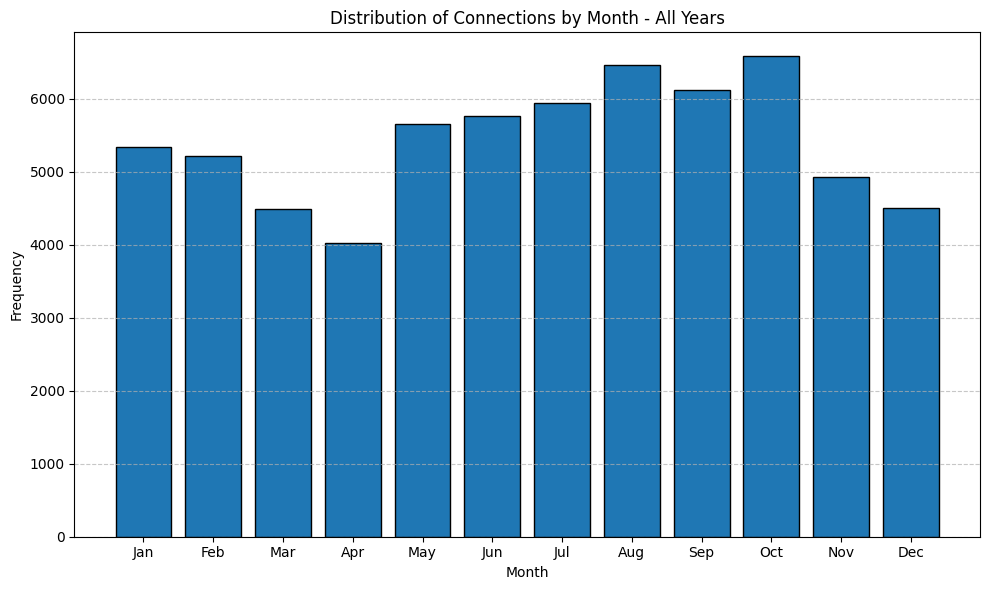

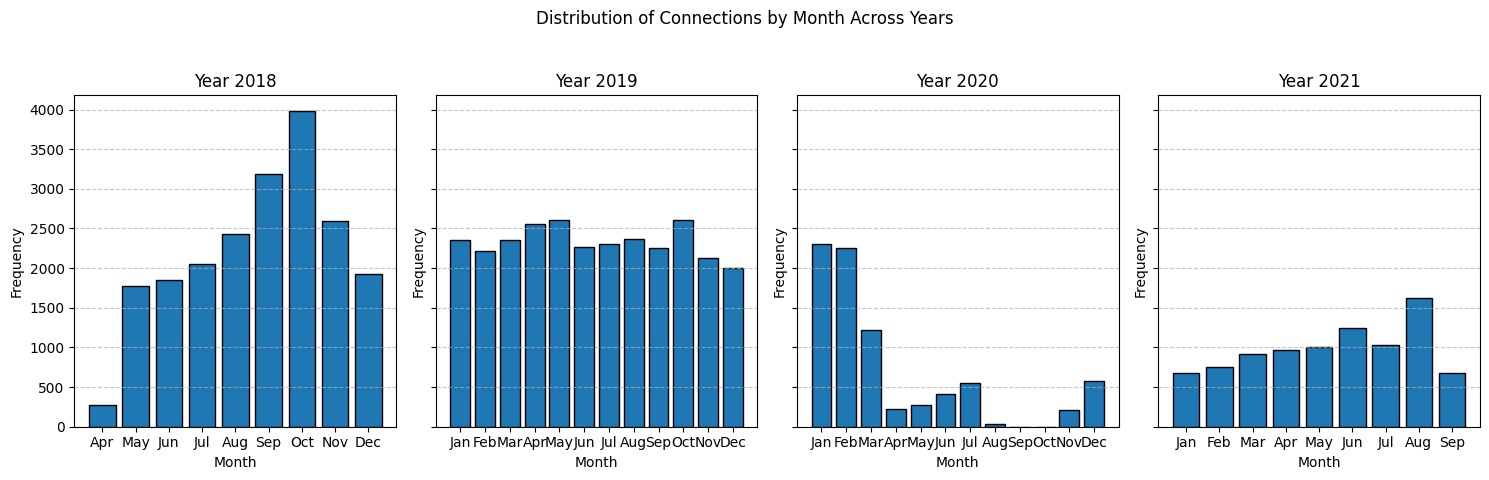

In [33]:
# Extract years from the DataFrame
years = [
    full_charging_df["connectionYear"].min() + year
    for year in range(
        full_charging_df["connectionYear"].max() - full_charging_df["connectionYear"].min() + 1
    )
]

# Create a dictionary of DataFrames by year
dfs_by_year = {
    year: full_charging_df[full_charging_df["connectionYear"] == year]
    for year in years
}

# Plot for all years combined
plot_hist(season_df=full_charging_df, title='Distribution of Connections by Month - All Years')

# Plot for each year individually
plot_hist(dfs_by_year=dfs_by_year, title="Distribution of Connections by Month Across Years")

Here there are a few things to see.
1. we start collecting records from April 2018 to September 2021
2. Somehow in March/April 2020 the data shows a steep fall while it never fully recovers to the old amounts
3. in September and October there don't seem to be any records

**April 2020 fall of records** 
The Fall in April 2020 can most likely be explained with Corona.
As suggested in this website: https://myburbank.com/latest-official-coronavirus-news-concerning-burbank/ (search for "March 22 – Burbank Gives Updated L. A, County Revised Order for Stronger “Safer at Home” Order") it may be due to the lockdown restrictions.

**September/October 2020 no records found**
The data for September and october looks a little bit different and needs further investigation

In [34]:
months = [4]
for month in months:
    monthly_data_2020 = dfs_by_year.get(2018)[dfs_by_year.get(2018)["connectionMonth"] == month]
    print(month ,set(monthly_data_2020['connectionTime'].dt.day))

4 {25, 26, 27, 28, 29, 30}


In [35]:
months = [8, 9, 10, 11]
for month in months:
    monthly_data_2020 = dfs_by_year.get(2020)[dfs_by_year.get(2020)["connectionMonth"] == month]
    print(month ,set(monthly_data_2020['connectionTime'].dt.day))

8 {1, 2, 3}
9 set()
10 set()
11 {18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}


This data implies that from the 03.08.2020 to the 17.11.2020 we collected no records may due to broken sensors or something similar.

In [36]:
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


Now we can explore the time data
Look for negative or NaN values

In [37]:
time_columns

['doneChargingTime',
 'connectionTime',
 'disconnectTime',
 'modifiedAt',
 'requestedDeparture']

In [38]:
for time_column in time_columns:
    print(f"{time_column}: {full_charging_df[time_column].isnull().sum()}")

doneChargingTime: 4087
connectionTime: 0
disconnectTime: 0
modifiedAt: 17215
requestedDeparture: 17215


In [39]:
# Define the critical columns
critical_columns = ['doneChargingTime', 'connectionTime', 'disconnectTime']

# Check for missing values and drop rows with missing values in the critical columns
missing_counts = full_charging_df[critical_columns].isnull().sum()
print("Missing value counts before dropping rows:")
print(missing_counts)

# Drop rows with missing values in any of the critical columns
full_charging_df = full_charging_df.dropna(subset=critical_columns)

# Verify the results
missing_counts_after = full_charging_df[critical_columns].isnull().sum()
print("\nMissing value counts after dropping rows:")
print(missing_counts_after)

print(f"\nRemaining rows: {len(full_charging_df)}")

Missing value counts before dropping rows:
doneChargingTime    4087
connectionTime         0
disconnectTime         0
dtype: int64

Missing value counts after dropping rows:
doneChargingTime    0
connectionTime      0
disconnectTime      0
dtype: int64

Remaining rows: 60950


In [40]:
for time_span_column in time_span_columns:
    negative_timedelta = full_charging_df[time_span_column] < pd.Timedelta(0)
    negative_count = negative_timedelta.sum()
    print(f"Before: {time_span_column}: {negative_count} rows with negative timespans")

    full_charging_df.loc[negative_timedelta, time_span_column] = pd.NaT
    
    negative_timedelta = full_charging_df[time_span_column] < pd.Timedelta(0)
    negative_count = negative_timedelta.sum()
    
    print(f"After: {time_span_column}: {negative_count} rows with negative timespans")

Before: connectionTimespan: 0 rows with negative timespans
After: connectionTimespan: 0 rows with negative timespans
Before: doneDisconnectTimespan: 4387 rows with negative timespans
After: doneDisconnectTimespan: 0 rows with negative timespans
Before: doneChargingTimespan: 27 rows with negative timespans
After: doneChargingTimespan: 0 rows with negative timespans


In [41]:
# These Negatives should not exist
part = full_charging_df[full_charging_df["doneDisconnectTimespan"] < pd.Timedelta(0)]
len(part)

0

In [42]:
len(full_charging_df["doneDisconnectTimespan"]) - len(part)

60950

In [43]:
# Calculate the timespan in which the car was connected to the station
full_charging_df["connectionTimespan"].describe()

count                        60950
mean     0 days 06:22:40.401197703
std      0 days 04:55:17.646112415
min                0 days 00:03:03
25%         0 days 02:58:28.500000
50%                0 days 06:18:25
75%                0 days 09:14:27
max               10 days 05:16:09
Name: connectionTimespan, dtype: object

In [44]:
# Final dataframe (currently)
full_charging_df.head()

,id,connectionTime,disconnectTime,doneChargingTime,kWhDelivered,sessionID,siteID,spaceID,stationID,timezone,...,connectionMonth,connectionWeekdayName,connectionYear,isWeekend,connectionHour,disconnectHour,doneChargingHour,loading_duration,connected_duration,ratio_loading_to_connected
0,5e23b149f9af8b5fe4b973cf,2020-01-02 05:08:54-08:00,2020-01-02 11:11:15-08:00,2020-01-02 09:31:35-08:00,25.016,1_1_179_810_2020-01-02 13:08:53.870034,1,AG-3F30,1-1-179-810,America/Los_Angeles,...,1,Thursday,2020,False,5,11,9.0,262.683333,362.350000,0.724944
1,5e23b149f9af8b5fe4b973d0,2020-01-02 05:36:50-08:00,2020-01-02 14:38:21-08:00,2020-01-02 12:18:05-08:00,33.097,1_1_193_825_2020-01-02 13:36:49.599853,1,AG-1F01,1-1-193-825,America/Los_Angeles,...,1,Thursday,2020,False,5,14,12.0,401.250000,541.516667,0.740974
2,5e23b149f9af8b5fe4b973d1,2020-01-02 05:56:35-08:00,2020-01-02 16:39:22-08:00,2020-01-02 08:35:06-08:00,6.521,1_1_193_829_2020-01-02 13:56:35.214993,1,AG-1F03,1-1-193-829,America/Los_Angeles,...,1,Thursday,2020,False,5,16,8.0,158.516667,642.783333,0.246610
3,5e23b149f9af8b5fe4b973d2,2020-01-02 05:59:58-08:00,2020-01-02 08:38:39-08:00,2020-01-02 07:18:45-08:00,2.355,1_1_193_820_2020-01-02 13:59:58.309319,1,AG-1F04,1-1-193-820,America/Los_Angeles,...,1,Thursday,2020,False,5,8,7.0,78.783333,158.683333,0.496481
4,5e23b149f9af8b5fe4b973d3,2020-01-02 06:00:01-08:00,2020-01-02 14:08:40-08:00,2020-01-02 10:17:30-08:00,13.375,1_1_193_819_2020-01-02 14:00:00.779967,1,AG-1F06,1-1-193-819,America/Los_Angeles,...,1,Thursday,2020,False,6,14,10.0,257.483333,488.650000,0.526928


We have now completed the data exploration and the preparation of the time-dependent data. We now need to decide how to deal with the invalid values we found during data exploration. If there is something we haven't seen yet, it will most likely come up when working on the other tasks.

In [45]:
# Set doneChargingTime to disconnectTime, if doneChargingTime is grater than disconnectTime
full_charging_df.loc[full_charging_df['doneChargingTime'] > full_charging_df['disconnectTime'], 'doneChargingTime'] = full_charging_df['disconnectTime']

# Set doneChargingTime to NaN if it is smaller than connectionTime
full_charging_df.loc[full_charging_df['doneChargingTime'] < full_charging_df['connectionTime'], 'doneChargingTime'] = np.nan

# # This code is generated by Copilot to save time codeing time. Copilot should generate the framework for an linear regression and i tried differnt x and y values to get a better prediction.
# # The code evolved in an iterative try and error approach also using copilot. 
# # Calculate the duration of the charging session, not the time until disconnection
# full_charging_df['chargingDuration'] = (full_charging_df['doneChargingTime'] - full_charging_df['connectionTime']).dt.total_seconds()
# 
# # Tries to fill null values in doneChargingTime with prediction based on connectionTimespan and kWhDelivered. Is Probably a bit too complex for the task and quality of predictions could still be better
# 
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import mean_squared_error
# import pandas as pd
# import numpy as np
# 
# 
# # Assuming full_charging_df is already loaded
# preprocess_df = full_charging_df.copy()
# 
# # Separate rows with and without null values in 'doneChargingTime'
# df_with_doneChargingTime = preprocess_df.dropna(subset=['doneChargingTime'])
# df_without_doneChargingTime = full_charging_df[full_charging_df['doneChargingTime'].isna()]
# 
# # Prepare data for training
# X = df_with_doneChargingTime[['connectionTimespanInSeconds', 'kWhDelivered', 'stationID', 'userID']]
# y = df_with_doneChargingTime['chargingDuration']
# 
# # One-Hot-Encoding für stationID und userID
# column_transformer = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), ['connectionTimespanInSeconds', 'kWhDelivered']),
#         ('cat', OneHotEncoder(handle_unknown='ignore'), ['stationID', 'userID'])
#     ],
#     remainder='passthrough'
# )
# 
# # Pipeline für die Transformation und das lineare Modell
# pipeline = Pipeline(steps=[
#     ('preprocessor', column_transformer),
#     ('regressor', LinearRegression())
# ])
# 
# # Aufteilen der Daten in Trainings- und Testdatensatz
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
# 
# # Trainieren des linearen Modells
# pipeline.fit(X_train, y_train)
# 
# # Vorhersagen und Evaluierung des linearen Modells
# y_pred = pipeline.predict(X_test)
# mse = mean_squared_error(y_test, y_pred)
# print(f'Mean Squared Error: {mse}')
# 
# differences = np.abs(y_test - y_pred)
# differences_in_hours = differences / 3600
# accurate_predictions = np.sum(differences_in_hours <= 1)
# total_predictions = len(y_test)
# accuracy_percentage = (accurate_predictions / total_predictions) * 100
# print(f'Prozentuale Genauigkeit: {accuracy_percentage:.2f}%')
# 
# # Vorhersagen für die Zeilen ohne doneChargingTime
# X_missing = df_without_doneChargingTime[['connectionTimespanInSeconds', 'kWhDelivered', 'stationID', 'userID']]
# X_missing_transformed = column_transformer.transform(X_missing)
# # Überprüfen der Anzahl der Merkmale nach der Transformation
# print(f'Anzahl der Merkmale nach der Transformation: {X_missing_transformed.shape[1]}')
# 
# y_missing_pred = pipeline.named_steps['regressor'].predict(X_missing_transformed)
# 
# # Aktualisieren der null-Werte in doneChargingTime mit den vorhergesagten Werten
# df_without_doneChargingTime.loc[:, 'chargingDuration'] = y_missing_pred
# 
# # Sicherstellen, dass connectionTimespan in float umgewandelt wird, bevor es in Timedelta konvertiert wird
# df_without_doneChargingTime.loc[:, 'connectionTimespanInSeconds'] = df_without_doneChargingTime['connectionTimespanInSeconds'].astype(float)
# df_without_doneChargingTime.loc[:, 'connectionTimespanInSeconds'] = pd.to_timedelta(df_without_doneChargingTime['connectionTimespanInSeconds'], unit='s')
# 
# # Berechnen der doneChargingTime
# df_without_doneChargingTime.loc[:, 'doneChargingTime'] = df_without_doneChargingTime['connectionTime'] + pd.to_timedelta(df_without_doneChargingTime['chargingDuration'], unit='s')
# 
# # Zusammenführen der DataFrames
# full_charging_df = pd.concat([df_with_doneChargingTime, df_without_doneChargingTime])
# 
# print(full_charging_df.head())


In [46]:
full_charging_df["connectionTimespan"].head()

0   0 days 06:02:21
1   0 days 09:01:31
2   0 days 10:42:47
3   0 days 02:38:41
4   0 days 08:08:39
Name: connectionTimespan, dtype: timedelta64[ns]

In [47]:
profile = ProfileReport(full_charging_df, title="Profiling Report")
profile.to_file("full_charging_data_report.pdf")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

/Users/mo/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-JrgwIgFo-py3.11/lib/python3.11/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.  0.  0. ... nan nan  0.]' has dtype incompatible with timedelta64[ns], please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/Users/mo/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-JrgwIgFo-py3.11/lib/python3.11/site-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with timedelta64[ns], please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/Users/mo/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-JrgwIgFo-

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

/Users/mo/Library/Caches/pypoetry/virtualenvs/aa-team-assignment-JrgwIgFo-py3.11/lib/python3.11/site-packages/ydata_profiling/profile_report.py:379: UserWarning: Extension .pdf not supported. For now we assume .html was intended. To remove this warning, please use .html or .json.
  warnings.warn(


Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [48]:
weather_profile = ProfileReport(df_weather, title="Profiling Report on Weather Data")
weather_profile.to_file("weather_data_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [49]:
# last cell should always save the data
df_weather.to_feather('../data/weather_burbank_airport.feather')
full_charging_df.to_feather('../data/full_charging_df.feather')